In [22]:
# Ячейка № 1

# вычисление и визуализация напряженности
# магнитного поля и векторного потенциала
# тороидальной обмотки с постоянным током
# в соответствие с (5.61) - (5.63)

# подключение библиотеки numpy
import numpy as np

# подключение графической библиотеки
import matplotlib.pyplot as plt

In [23]:
# Ячейка № 2

# задание функции, возвращающей значения
# проекций напряженности магнитного поля
# на оси oY, oZ, вычисляемые
# в соответствие с (5.61)-(5.63)
def Tor(x0, y0, z0, Rt, a, N):
    # x0, y0, z0 - координаты радиуса-вектора
    #              точки наблюдения
    # Rt - радиус большого кольца тора
    # a - радиус малого кольца тора
    # N - число витков обмотки

    # задание числа элементов, используемых для
    # аппроксимации обмотки соленоида
    Nstep = 200

    # вычисление координат узлов сетки по переменной phi
    N_phi = N * Nstep
    phi = np.linspace(0, 2 * np.pi, N_phi)

    # инициализация массивов, используемых для хранения
    # значений подынтегральных функций в (5.61)-(5.63)
    bx = np.zeros(N_phi)
    by = np.zeros(N_phi)
    bz = np.zeros(N_phi)

    # вычисление значений подынтегральный функций в (5.61)-(5.63)
    for n in range(N_phi):
        # вычисление координат вектора r в соответствие с (5.54)
        rx = (Rt + a * np.cos(N * phi[n])) * np.cos(phi[n])
        ry = (Rt + a * np.cos(N * phi[n])) * np.sin(phi[n])
        rz = a * np.sin(N * phi[n])

        # вычисление координат вектора t
        # в соответствие с (5.57)
        tx = -(
            Rt * np.sin(phi[n])
            + a * np.sin(phi[n]) * np.cos(N * phi[n])
            + a * N * np.sin(N * phi[n]) * np.cos(phi[n])
        )
        ty = (
            Rt * np.cos(phi[n])
            - N * a * np.sin(phi[n]) * np.sin(N * phi[n])
            + a * np.cos(N * phi[n]) * np.cos(phi[n])
        )
        tz = a * N * np.cos(N * phi[n])

        # вычисление координат вектора R0-r
        # в соответствие с (5.59)
        Rx = x0 - rx
        Ry = y0 - ry
        Rz = z0 - rz

        # вычисление модуля вектора R0-r
        R = np.sqrt(Rx**2 + Ry**2 + Rz**2)

        # вычисление значений
        # подынтегральных функций в (5.61)-(5.63)
        bx[n] = (ty * Rz - tz * Ry) / R**3
        by[n] = (tx * Rz - tz * Rx) / R**3
        bz[n] = (tx * Ry - ty * Rx) / R**3

    # вычисление значений
    # интегралов (5.61)-(5.63)
    # методом трапеций
    return np.trapz(bx, phi), np.trapz(by, phi), np.trapz(bz, phi)


In [ ]:
# Ячейка № 3

# задание функции, возвращающей
# значения проекций векторного потенциала
# магнитного поля на оси oY, oZ,
# вычисляемые в соответствии с (5.65)-(5.67)
def TorA(x0, y0, z0, Rt, a, N):
    # x0, y0, z0 - координаты радиуса-вектора
    #              точки наблюдения
    # Rt - радиус большого кольца тора
    # a - радиус малого кольца тора
    # N - число витков обмотки

    # задание числа элементов, используемых для
    # аппроксимации обмотки соленоида
    Nstep = 200

    # вычисление координат узлов сетки по переменной phi
    N_phi = N * Nstep
    phi = np.linspace(0, 2 * np.pi, N_phi)

    # инициализация массивов, используемых для хранения
    # значений подынтегральных функций в (5.65)-(5.67)
    ax = np.zeros(N_phi)
    ay = np.zeros(N_phi)
    az = np.zeros(N_phi)

    # вычисление значений
    # подынтегральный функций в (5.65)-(5.67)
    for n in range(N_phi):
        # вычисление координат вектора r
        # в соответствие с (5.57)
        rx = (Rt + a * np.cos(N * phi[n])) * np.cos(phi[n])
        ry = (Rt + a * np.cos(N * phi[n])) * np.sin(phi[n])
        rz = a * np.sin(N * phi[n])

        # вычисление координат вектора t
        # в соответствие с (5.57)
        tx = -(
            Rt * np.sin(phi[n])
            + a * np.sin(phi[n]) * np.cos(N * phi[n])
            + a * N * np.sin(N * phi[n]) * np.cos(phi[n])
        )
        ty = (
            Rt * np.cos(phi[n])
            - N * a * np.sin(phi[n]) * np.sin(N * phi[n])
            + a * np.cos(N * phi[n]) * np.cos(phi[n])
        )
        tz = a * N * np.cos(phi[n])

        # вычисление координат вектора R0-r
        # в соответствие с (5.59)
        Rx = x0 - rx
        Ry = y0 - ry
        Rz = z0 - rz

        # вычисление модуля вектора R0-r
        R = np.sqrt(Rx**2 + Ry**2 + Rz**2)

        # вычисление значений
        # подынтегральных функций в (5.65)-(5.67)
        ax[n] = tx / R
        ay[n] = ty / R
        az[n] = tz / R

    # вычисление значений
    # интегралов (5.65)-(5.67)
    # методом трапеций
    Ax = np.trapz(ax, phi)
    Ay = np.trapz(ay, phi)
    Az = np.trapz(az, phi)

    # вычисление модуля
    # векторного потенциала
    return np.sqrt(Ax**2 + Ay**2 + Az**2)


In [ ]:
# Ячейка № 4

# вычисление значений составляющих
# напряженности магнитного поля By, Bz
# вычисляемых в соответствие с (5.62), (5.63)

# задание числа узлов координатной сетки
N1 = 21

# задание значений координат
# левого нижнего и правого верхнего
# узлов координатной сетки
Ymin = -10
Ymax = 10
Zmin = -10
Zmax = 10

# задание ординат узлов координатной сетки
Y = np.linspace(Ymin, Ymax, N1)

# задание аппликат узлов координтаной сетки
Z = np.linspace(Zmin, Zmax, N1)
Ny = len(Y)
Nz = len(Z)

# создание матриц, используемых для визуализации
# векторного поля
[Y1, Z1] = np.meshgrid(Y, Z)

# задание радиуса кольца с током
a = 0.5
Rt = 1
N = 10

# инициализация массивов, используемых для
# для хранения значений составляющих
# напряженности магнитного поля,
# вычисляемых в соответствие с (5.62), (5.63)
By = np.zeros([len(Y), len(Z)])
Bz = np.zeros([len(Y), len(Z)])

# вычисление значений составляющих напряженностей
# магнитного поля в соответствие с (5.62), (5.63)
#  в узлах выбранной координатной сетки
for i in range(Ny):
    for j in range(Nz):
        bx, by, bz = Tor(0, Y1[i, j], Z1[i, j], Rt, a, N)
        By[i, j] = by
        Bz[i, j] = bz

# инициализация массива mp, используемого для
# для хранения значений модуля напряженности
# магнитного поля, вычисленных
# в узлах выбранной координатной сетки
mp = np.zeros([Ny, Nz])

# вычисление значения модуля напряженности
# магнитного поля в соответствие с (5.62), (5.63)
# в узлах выбранной координатной сетки
for i in range(Ny):
    for j in range(Nz):
        mp[i, j] = np.sqrt(By[i, j] ** 2 + Bz[i, j] ** 2)

# инициализация массивов by1, bz1, используемых для
# для хранения значений координат единичных векторов,
# касательных к силовой линии магнитного поля,
# в узлах выбранной координатной сетки
by1 = np.zeros([Ny, Nz])
bz1 = np.zeros([Ny, Nz])

# вычисление абсцисс и аппликат единичных векторов,
# касательных к силовой линии магнитного поля,
# в узлах выбранной координатной сетки
for i in range(Ny):
    for j in range(Nz):
        by1[i, j] = By[i, j] / mp[i, j]
        bz1[i, j] = Bz[i, j] / mp[i, j]


In [ ]:
# Ячейка № 5

# вычисление модуля векторного потенциала
# магнитного поля в узлах
# выбранной координатной сетки


# задание числа узлов координатной сетки,
# используемой для расчета и визуализаций
# модуля векторного потенциала
N1 = 51

# вычисление значений ординат узлов координатной сетки,
# используемой для расчета и визуализаций
# модуля векторного потенциала
y = np.linspace(Ymin, Ymax, N1)

# вычисление значений аппликат узлов координатной сетки
z = np.linspace(Zmin, Zmax, N1)

# создание матриц, используемых для визуализации
# эквипотенциалей векторного потенциала
# магнитного поля
[Y2, Z2] = np.meshgrid(y, z)


# вычисление модуля векторного потенциала
Ny2 = len(y)
Nz2 = len(z)

# инициализация массива A, используемого для
# для хранения значений модуля
# векторного потенциала магнитного поля
# в узлах выбранной координатной сетки
A = np.zeros([Ny2, Nz2])
for i in range(Ny2):
    for j in range(Nz2):
        A[i, j] = TorA(0, Y2[i, j], Z2[i, j], Rt, a, N)

In [ ]:
# Ячейка № 6

# вычисление значений
# модуля напряженностей магнитного поля
# в плоскости YOZ вдоль линий y = 0, z = 0

# задание числа узлов координатной сетки
N1 = 401

# задание ординат узлов координатной сетки
y = np.linspace(Ymin, Ymax, N1)

# задание аппликат узлов координатной сетки
z = np.linspace(Zmin, Zmax, N1)
Ny2 = len(y)
Nz2 = len(z)

# инициализация массива b1,
# используемого для хранения
# значений зависимости |B(0,0,z)|
b1 = np.zeros(Nz2)

# вычисление значений зависимости |B(0,0,z)|
for i in range(Nz2):
    bx, by, bz = Tor(0, 0, z[i], Rt, a, N)
    b1[i] = np.sqrt(by**2 + bz**2)

# инициализация массива b2,
# используемого для хранения
# значений зависимости |B(0,0,z)|
b2 = np.zeros(Ny2)

# вычисление значений зависимости |B(0,y,0)|
for i in range(Ny2):
    bx, by, bz = Tor(0, y[i], 0, Rt, a, N)
    b2[i] = np.sqrt(by**2 + bz**2)


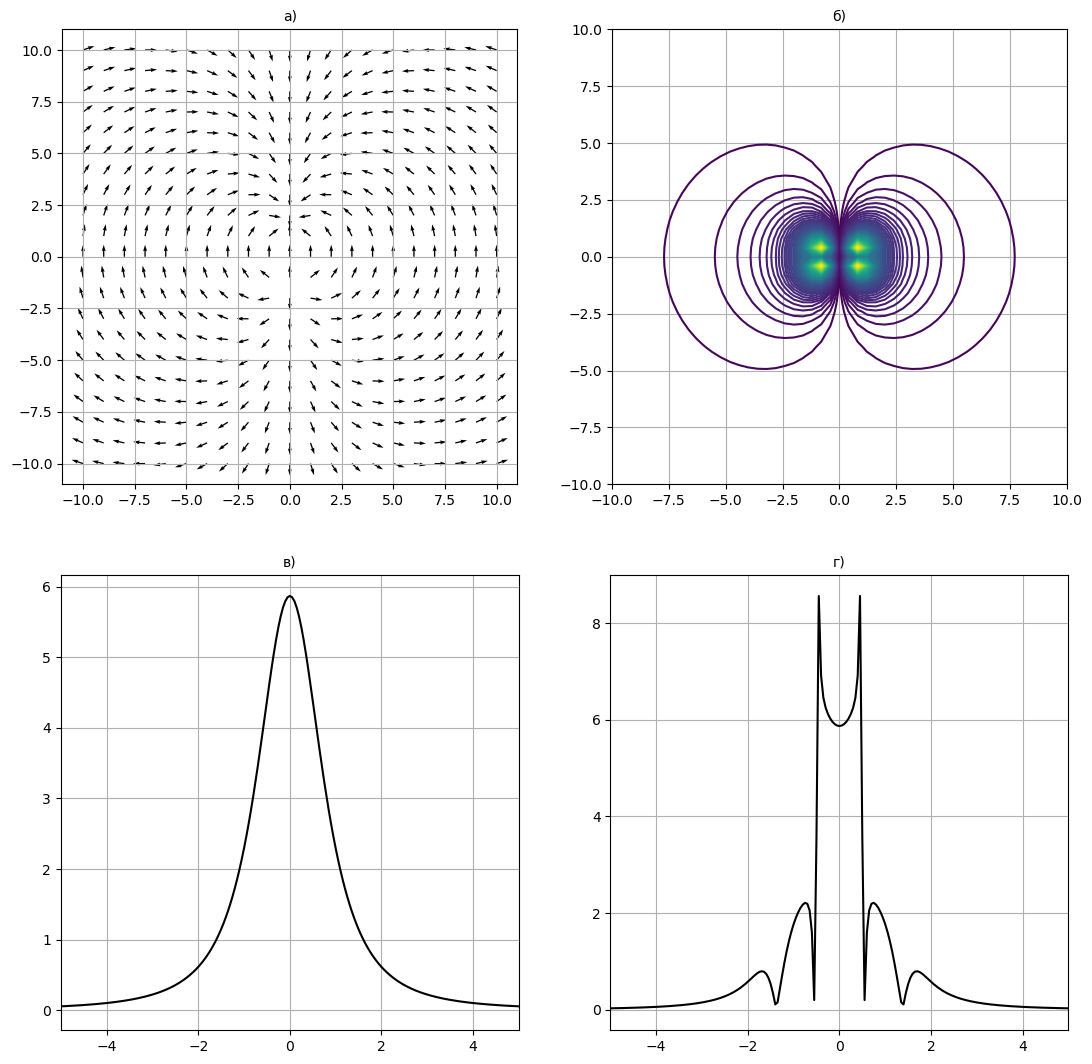

In [28]:
# Ячейка № 7

# визуализация поля единичных векторов,
# касательных к силовой линии магнитного поля,
# и его силовых линий
# в узлах выбранной координатной сетки
fig = plt.figure(figsize=(13, 13))

# визуализация поля единичных векторов,
# касательных к силовой линии магнитного поля,
# в узлах выбранной координатной сетки
ax = fig.add_subplot(221)
ax.quiver(Z1, Y1, by1, bz1)
ax.set_aspect("equal", "box")
ax.grid(True)
plt.title(r"а)", fontsize=10)

# визуализация силовых линий магнитного поля,
# в узлах выбранной координатной сетки
ax = fig.add_subplot(222)
CS = ax.contour(Y2, Z2, A, levels=77)
ax.set_aspect("equal", "box")
ax.grid(True)
plt.title(r"б)", fontsize=10)

# визуализация зависимости |B(0,0,z)|
ax = fig.add_subplot(223)
ax.plot(z, b1, "-k")
plt.xlim(-5, 5)
ax.grid(True)
plt.title(r"в)", fontsize=10)

# визуализация зависимости |B(0,y,0)|
ax = fig.add_subplot(224)
ax.plot(y, b2, "-k")
plt.xlim(-5, 5)
ax.grid(True)
plt.title(r"г)", fontsize=10)

plt.show()
